In [222]:
from pathlib import Path
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


DATA_BASE_PATH = "../local/Tvarminne/preprocessed_all"

path = Path(f"{DATA_BASE_PATH}/")
files_to_process = path.glob("*.csv")
dfs = []
for file in files_to_process:
    df = pd.read_csv(file, engine='pyarrow', index_col="Time")
    # df = df[~df.index .duplicated(keep="first")]
    df.sort_index()
    dfs.append(df)

df = pd.concat(dfs, axis=1, sort=True)
df.columns = df.columns.str.split('_').str[0]

PAIRS_TO_MASK = [
    # ("CHL", "Reagents"),
]

def plot_corr_matrix(df_c, title, method="pearson"):
    threshold = 0
    corr = df_c.corr(method=method)
    mask_high_corr = corr.abs() < threshold
    
    # high_corr = (corr.where(np.eye(corr.shape[0],dtype=bool))
    #                     .stack()
    #                     .sort_values(ascending=False))

    mask_ignore = pd.DataFrame(False, index=corr.index, columns=corr.columns)

    for f1, f2 in PAIRS_TO_MASK:
        mask_ignore.loc[f1, f2] = True
        mask_ignore.loc[f2, f1] = True

    mask = mask_ignore | mask_high_corr

    plt.figure(figsize=(10,10))

    cmap = plt.cm.coolwarm.copy()
    cmap.set_bad(color="lightgray") 

    sns.heatmap(
        corr, 
        xticklabels=1, 
        yticklabels=1,
        vmin=-1, 
        vmax=1, 
        center=0, 
        mask=mask,
        cmap=cmap,
        linewidths=0.5,      
        linecolor="white",
        # title=title
        # annot=True,
        # annot_kws={"size": 3}
        )
    plt.title(title)

    plt.show()

# hierarchical agglomerative clustering based on correlation distance

In [223]:
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.cluster.hierarchy import dendrogram
from scipy.spatial.distance import pdist, squareform

def cluster(df_x, method="pearson"):
    corr = df_x.corr(method=method).abs()
    distance = 1 - corr
    distance = distance.fillna(1.0)
    condensed_distance = squareform(distance.values)

    Z = linkage(condensed_distance, method='average')
    cluster_labels = fcluster(Z, t=0.3, criterion='distance')
    groups = pd.DataFrame({'feature': corr.columns, 'cluster': cluster_labels})
    groups = groups.sort_values('cluster')
    clusters = groups.groupby('cluster')['feature'].apply(list)

    return clusters, corr, Z

def plot_dentogram(df_dent, title, method="pearson"):
    clusters_den, corr_den, Z_den = cluster(df_dent)
    plt.figure(figsize=(12, 6))
    dendrogram(Z_den, labels=df_dent.columns, leaf_rotation=90, color_threshold=0.4)
    plt.tight_layout()
    plt.title(title)
    plt.show()

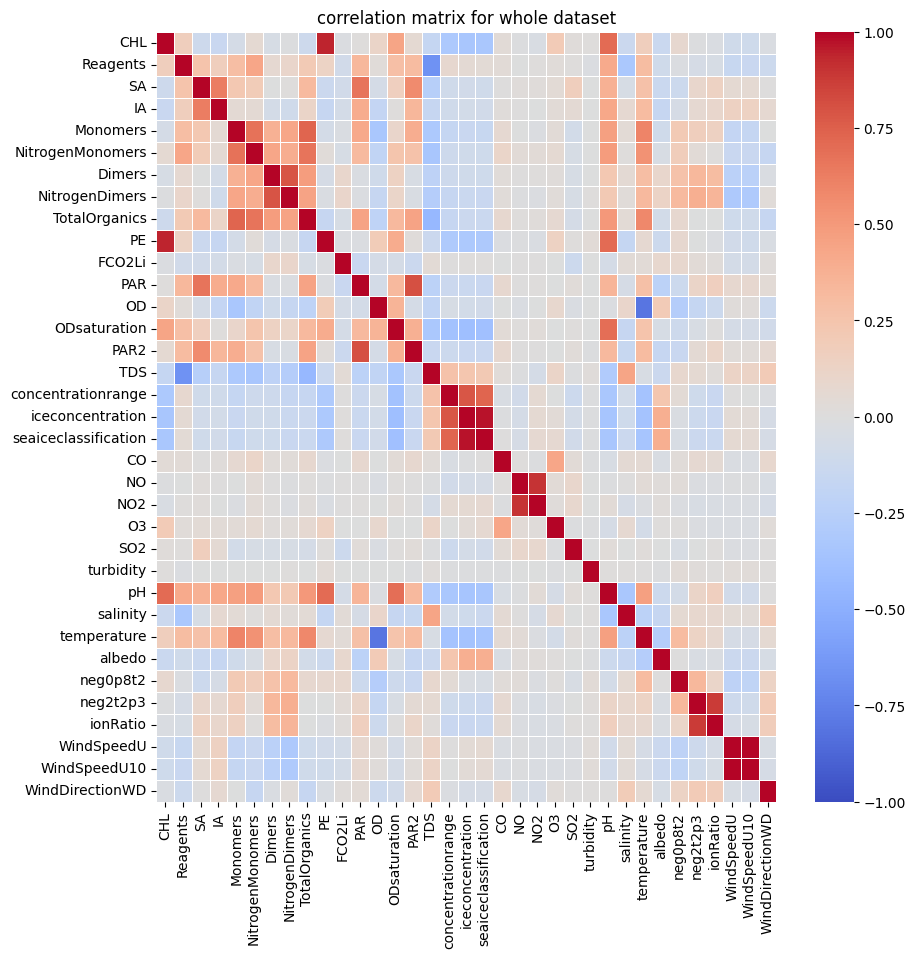

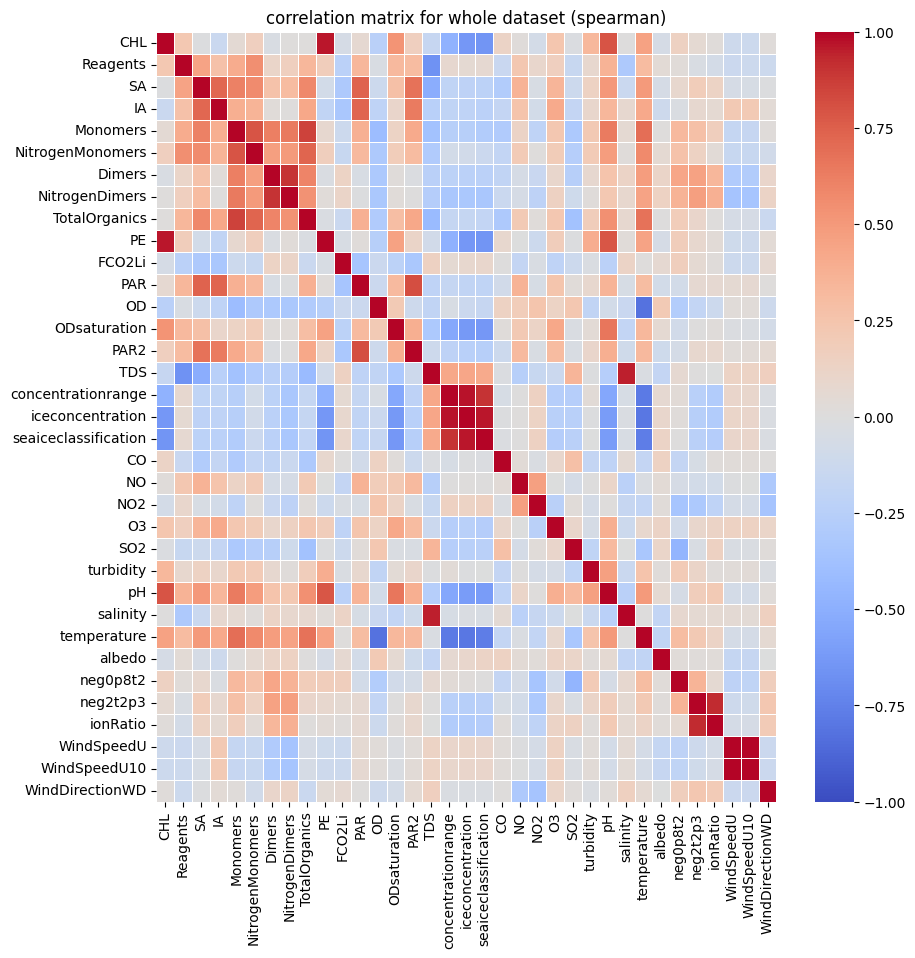

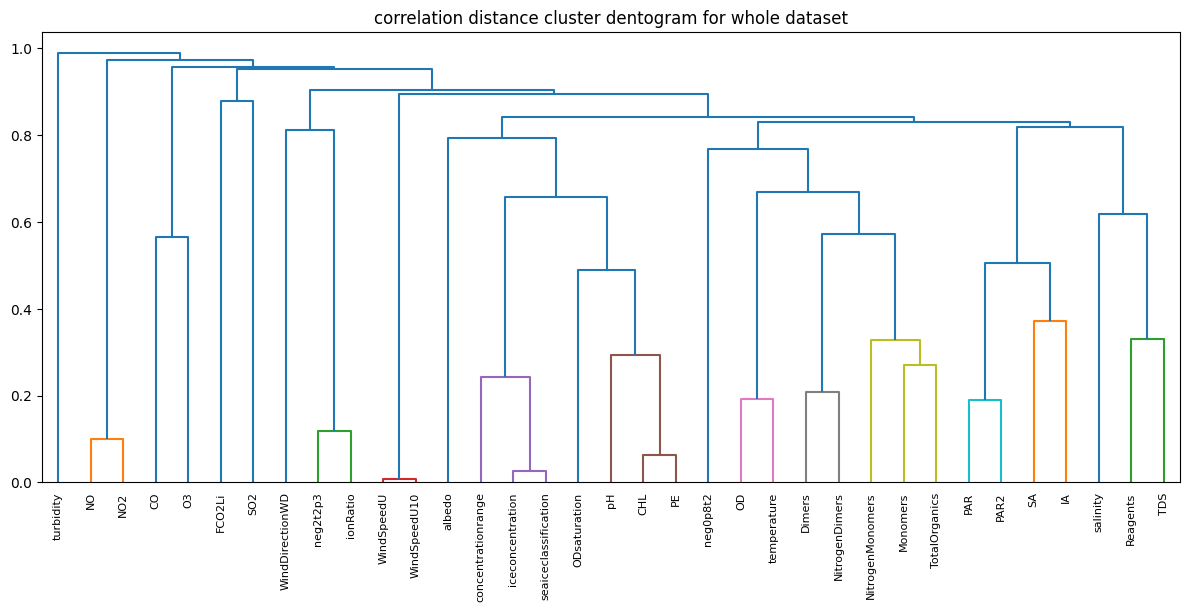

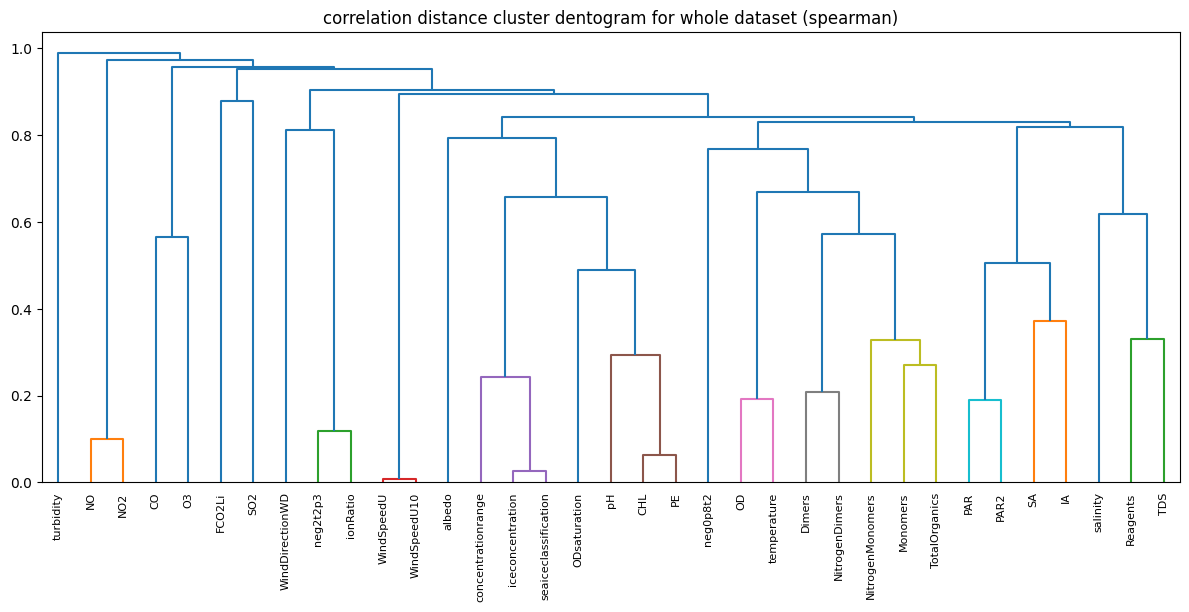

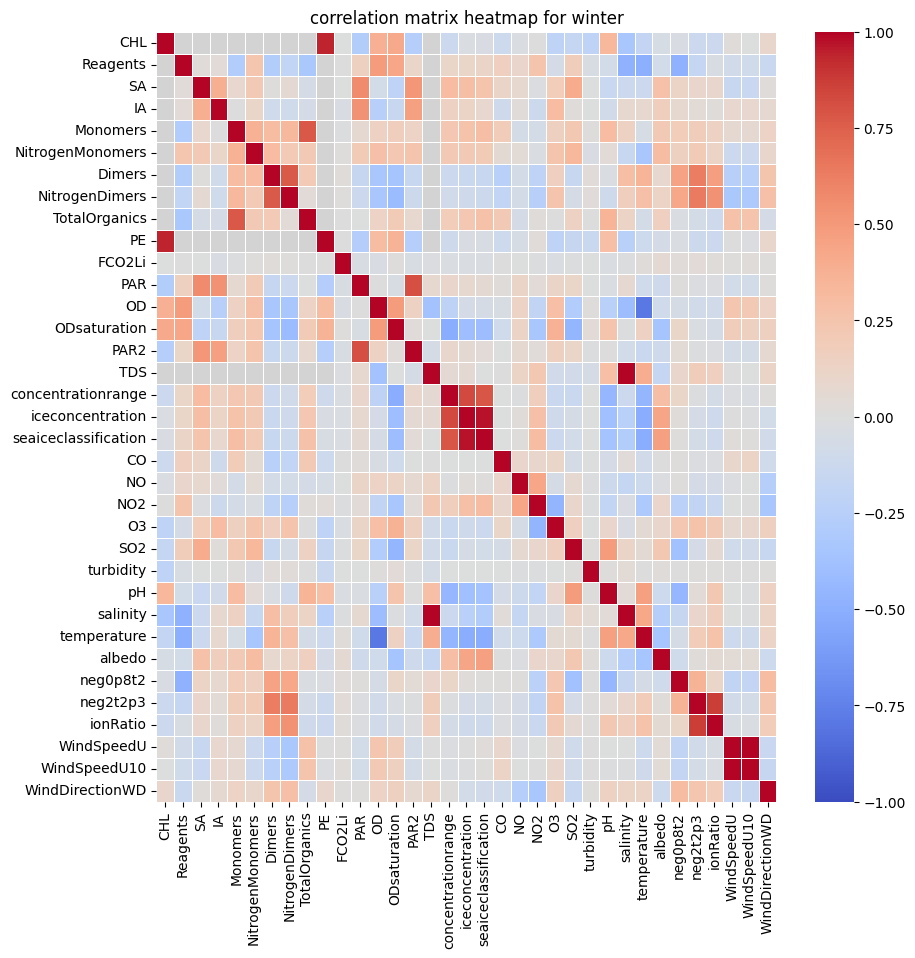

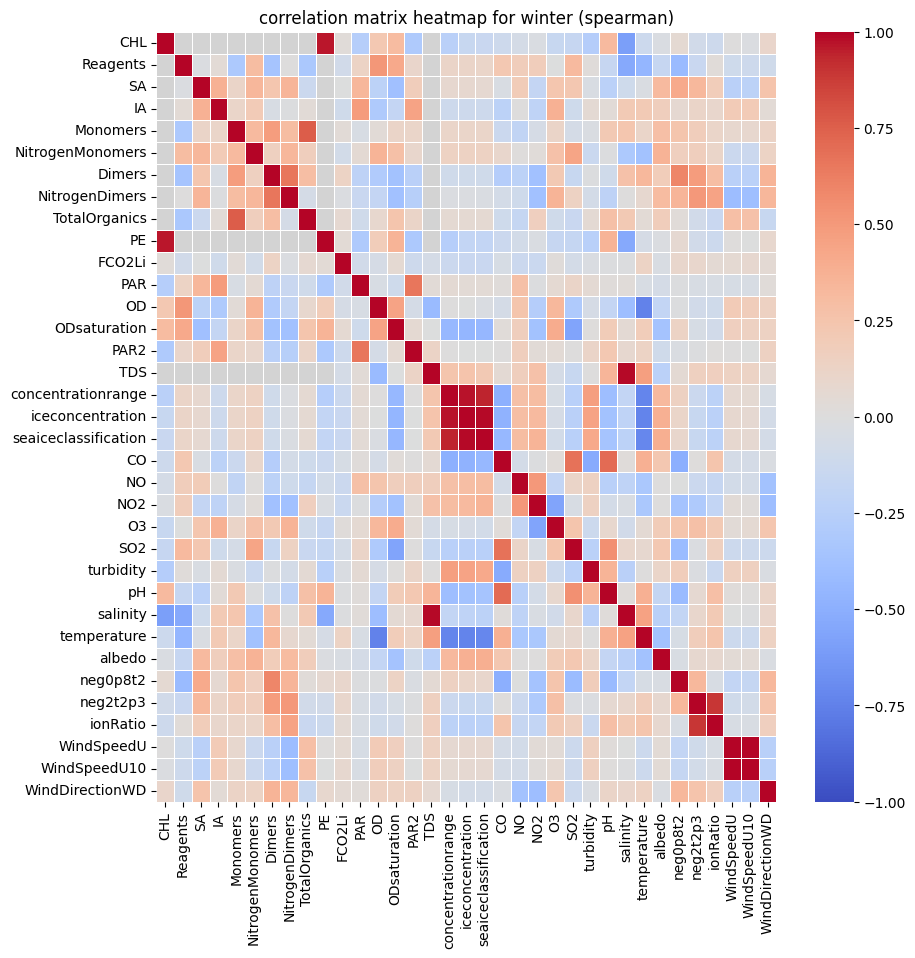

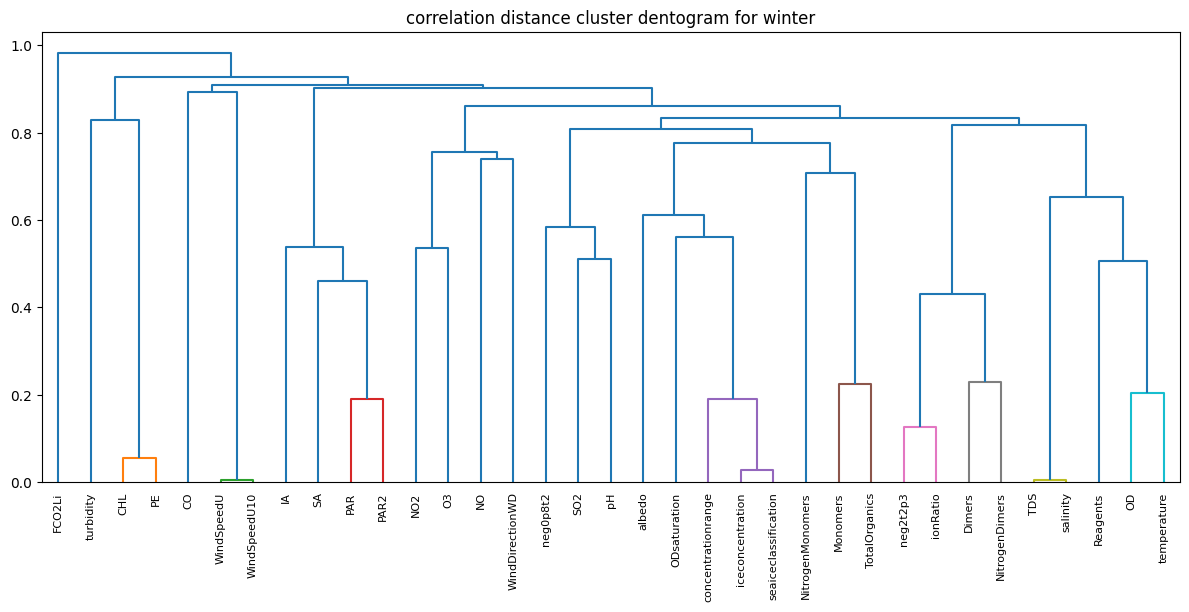

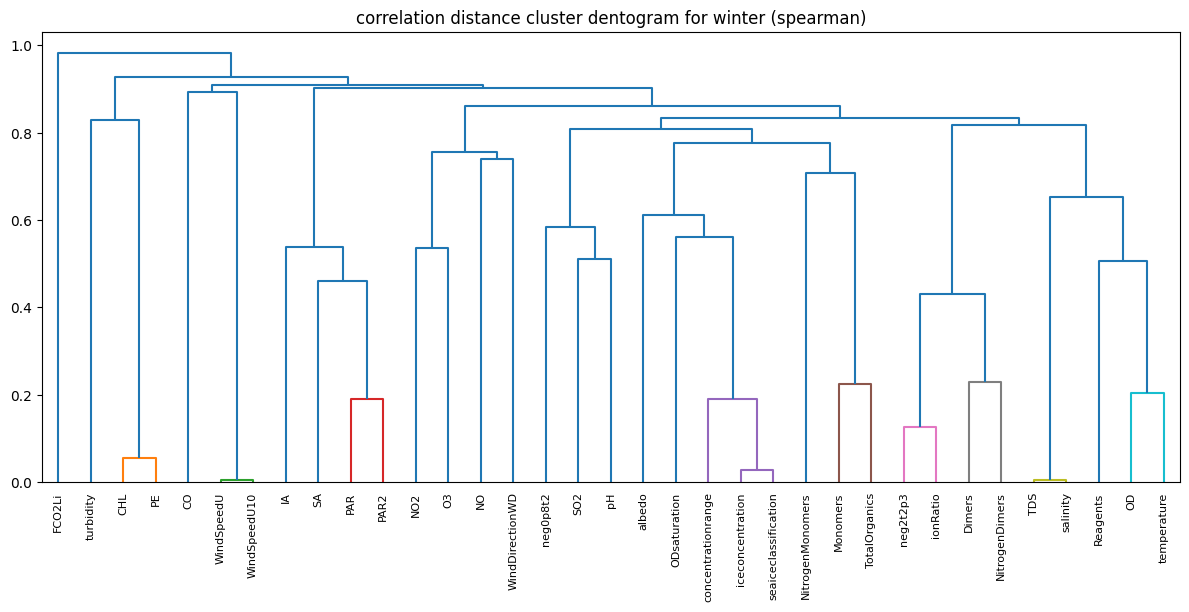

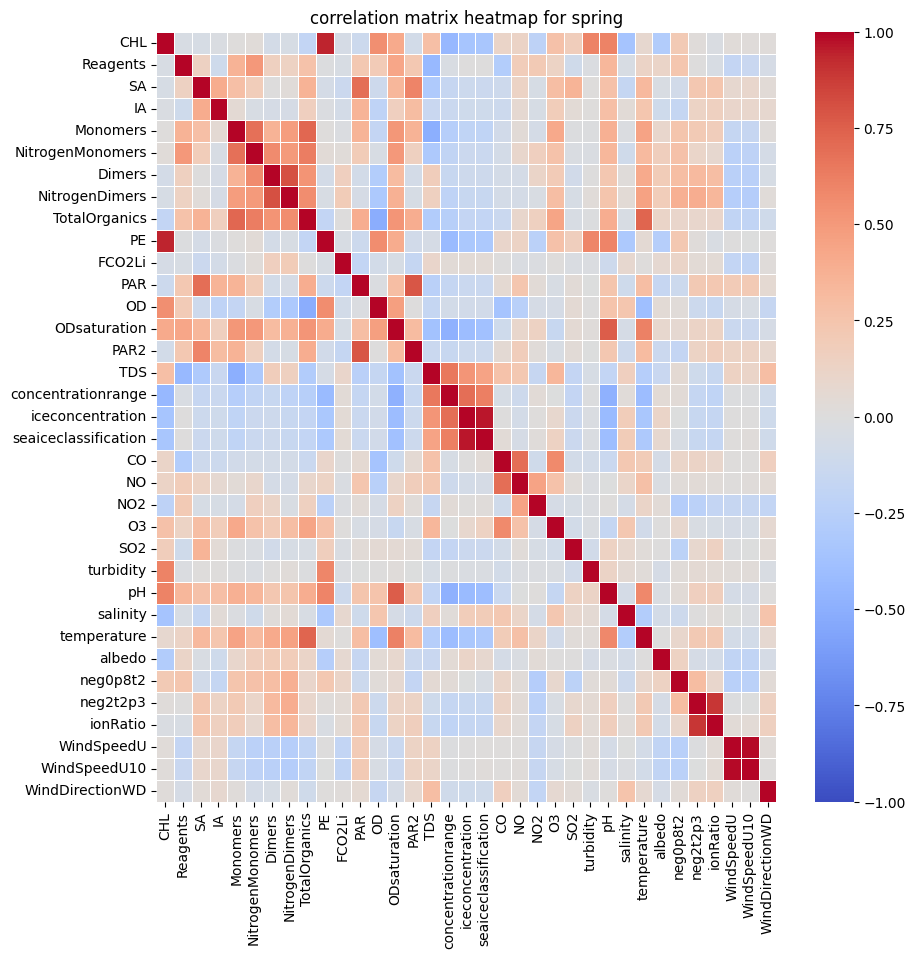

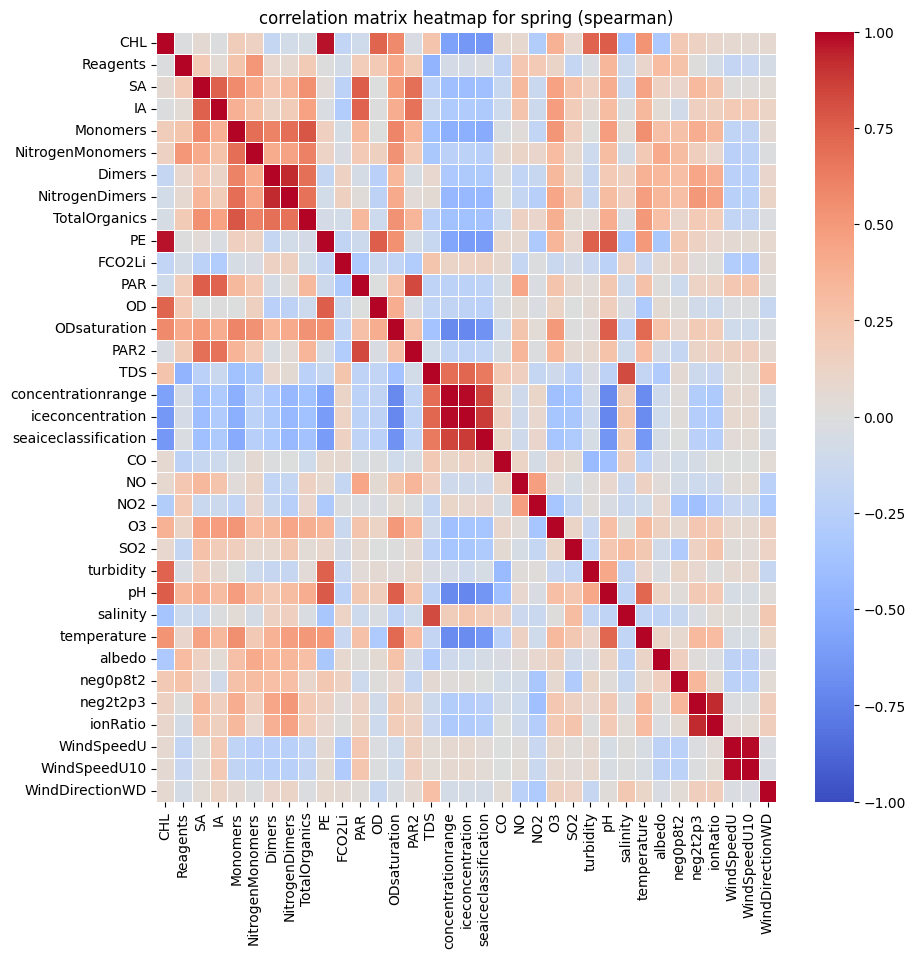

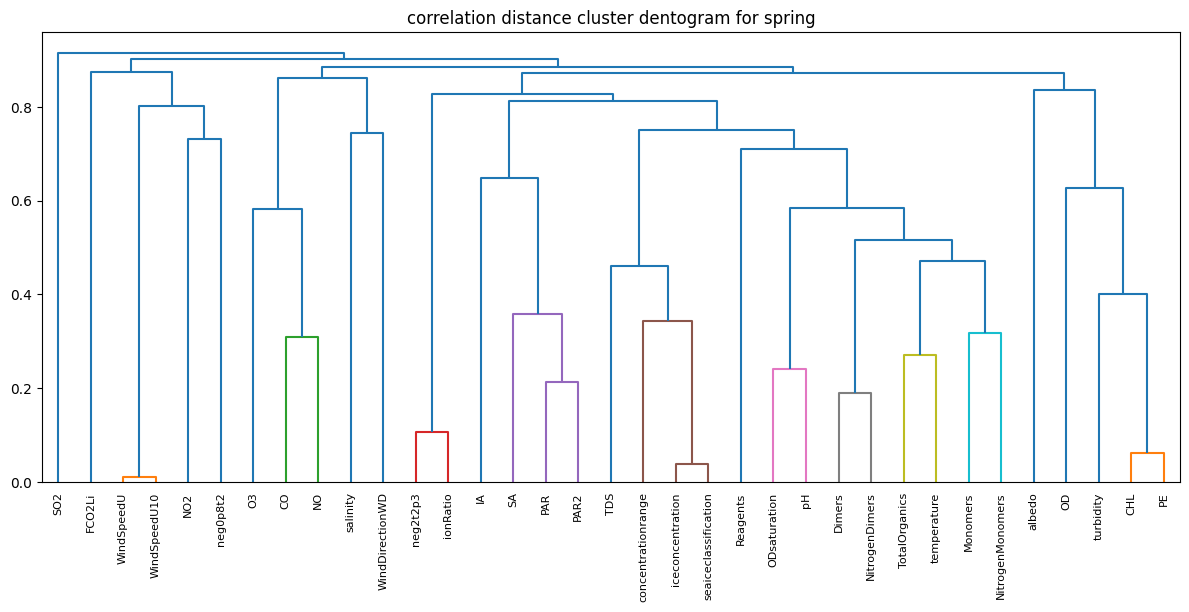

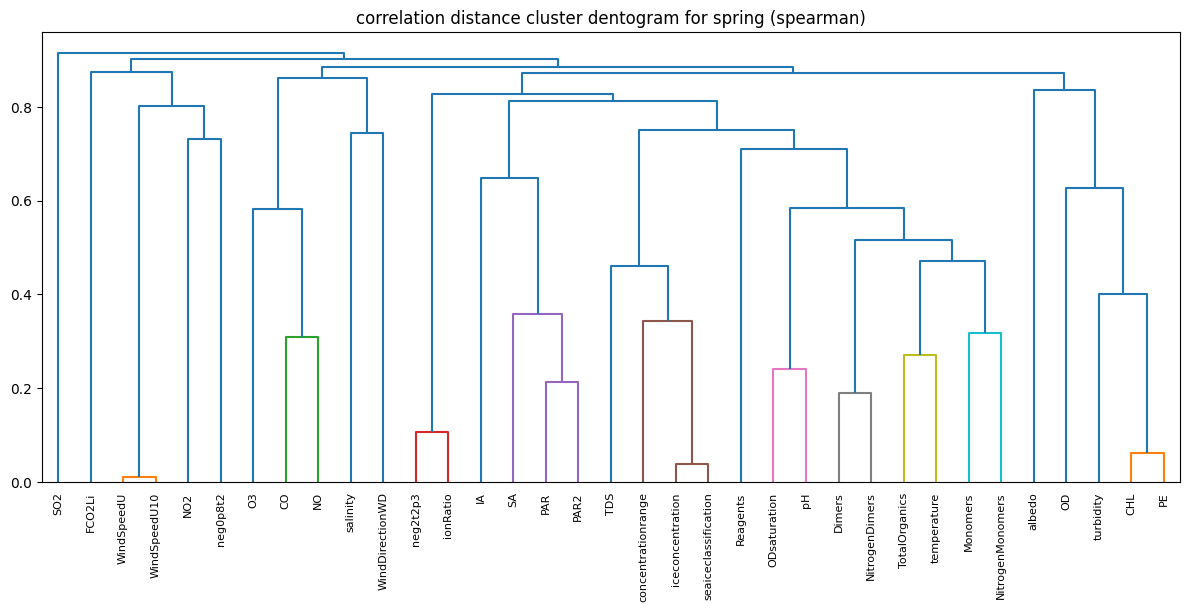

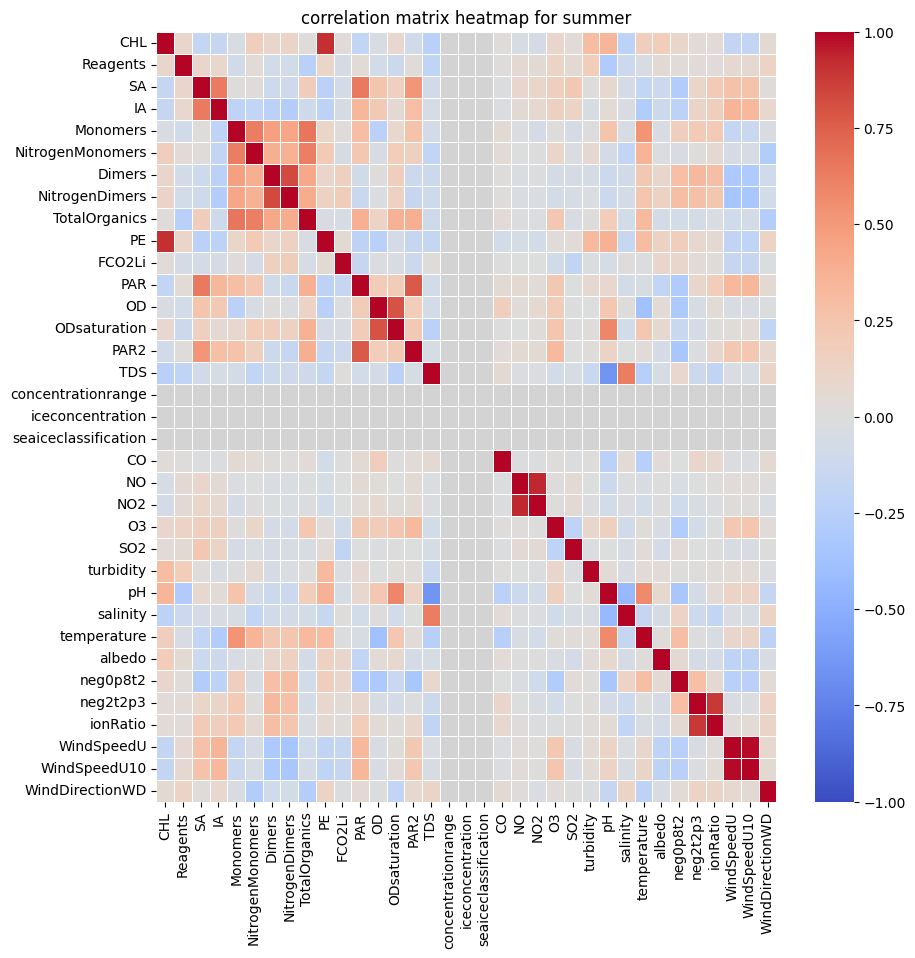

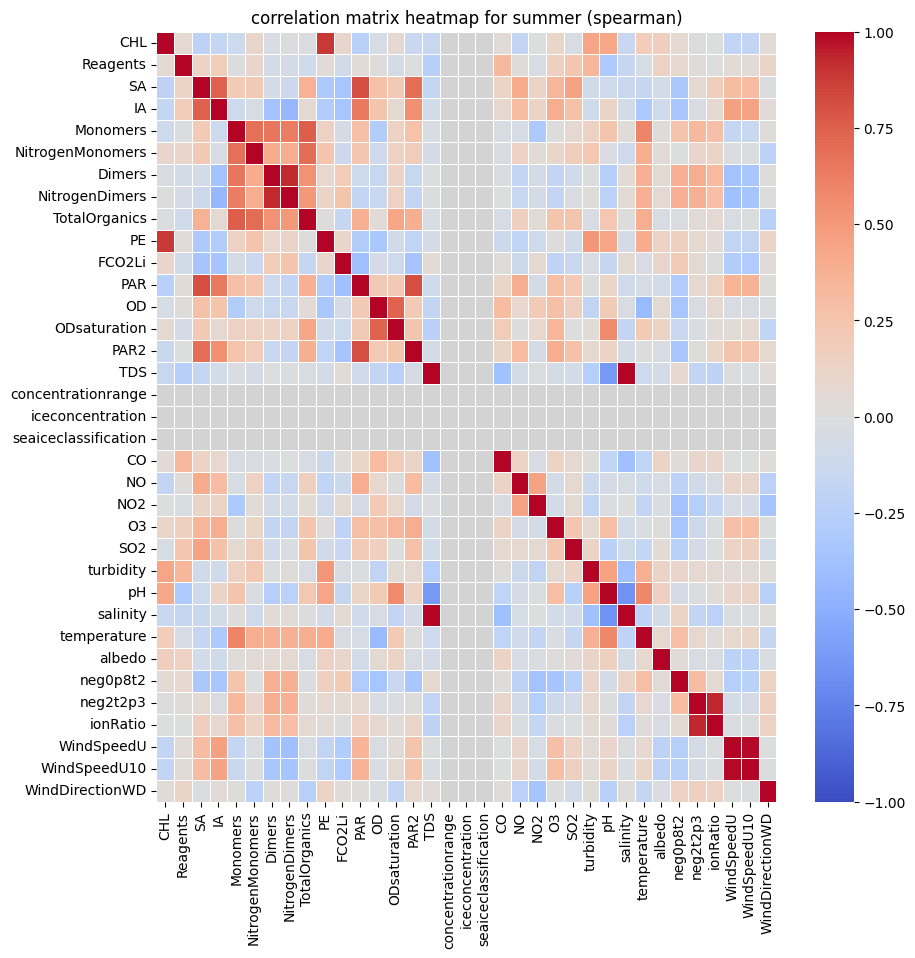

ValueError: Distance matrix 'X' diagonal must be zero.

In [224]:

KEY_WINTER = "winter"
KEY_SPRING = "spring"
KEY_SUMMER = "summer"
KEY_AUTUMN = "autumn"

SEASONS = [KEY_WINTER, KEY_SPRING, KEY_SUMMER, KEY_AUTUMN]

MONTH_SEASON_MAP = {
    1: SEASONS[0],
    2: SEASONS[0],
    3: SEASONS[1],
    4: SEASONS[1],
    5: SEASONS[1],
    6: SEASONS[2],
    7: SEASONS[2],
    8: SEASONS[2],
    9: SEASONS[3],
    10: SEASONS[3],
    11: SEASONS[3],
    12: SEASONS[0]
}
df_seasoned = df.copy()
df_seasoned["season"] = df_seasoned.index.month.map(MONTH_SEASON_MAP) 


dfs_s = []
for season in SEASONS:
    df_s = df_seasoned[df_seasoned["season"] == season]
    dfs_s.append(df_s)

METHOD_SPEARMAN="spearman"

plot_corr_matrix(df, "correlation matrix for whole dataset")
plot_corr_matrix(df, f"correlation matrix for whole dataset ({METHOD_SPEARMAN})", method=METHOD_SPEARMAN)

plot_dentogram(df, "correlation distance cluster dentogram for whole dataset")
plot_dentogram(df, f"correlation distance cluster dentogram for whole dataset ({METHOD_SPEARMAN})", method=METHOD_SPEARMAN)

for df_season in dfs_s:
    s = df_season["season"].iloc[0]
    df_s_c = df_season.drop(["season"], axis=1)
    plot_corr_matrix(df_s_c, f"correlation matrix heatmap for {s}")
    plot_corr_matrix(df_s_c, f"correlation matrix heatmap for {s} ({METHOD_SPEARMAN})", method=METHOD_SPEARMAN)

    plot_dentogram(df_s_c, f"correlation distance cluster dentogram for {s}")
    plot_dentogram(df_s_c, f"correlation distance cluster dentogram for {s} ({METHOD_SPEARMAN})", method=METHOD_SPEARMAN)

    # plot_dentogram(df_season.drop(["season"], axis=1), f"dentogram for {df_season["season"].iloc[0]}")